In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import kagglehub
import seaborn as sns

# Install ydata-profiling as it's a common data profiling library
!pip install ydata-profiling --quiet

# Updated import for ProfileReport
from ydata_profiling import ProfileReport

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.1 MB/s eta 0:00:00


/tmp/ipykernel_2034/299884303.py:12: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("austinreese/craigslist-carstrucks-data")

print("Path to dataset files:", path)

100%|██████████| 262M/262M [00:02<00:00, 105MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/austinreese/craigslist-carstrucks-data/versions/10


In [3]:
csv_path = os.path.join(path, "vehicles.csv")

df_cars = pd.read_csv(csv_path)
df_cars.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


In [4]:
# قائمة بالأعمدة التي عادة ما تدمر الرام في بيانات Craigslist ولا تفيد في توقع السعر
columns_to_drop = [
    'url', 'image_url', 'region_url', 'id', 'vin',
    'description'  # عمود model يحتوي على آلاف الموديلات الفريدة ويفضل حذفه أو استخدام Target Encoding بدلاً من One-Hot
]

# التأكد من وجود الأعمدة قبل حذفها لتجنب الأخطاء
columns_to_drop_existing = [col for col in columns_to_drop if col in df_cars.columns]
df_cars = df_cars.drop(columns=columns_to_drop_existing)

In [5]:

df_cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 21 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        426880 non-null  object 
 1   price         426880 non-null  int64  
 2   year          425675 non-null  float64
 3   manufacturer  409234 non-null  object 
 4   model         421603 non-null  object 
 5   condition     252776 non-null  object 
 6   cylinders     249202 non-null  object 
 7   fuel          423867 non-null  object 
 8   odometer      422480 non-null  float64
 9   title_status  418638 non-null  object 
 10  transmission  424324 non-null  object 
 11  VIN           265838 non-null  object 
 12  drive         296313 non-null  object 
 13  size          120519 non-null  object 
 14  type          334022 non-null  object 
 15  paint_color   296677 non-null  object 
 16  county        0 non-null       float64
 17  state         426880 non-null  object 
 18  lat 

In [6]:
df_cars.describe()

,price,year,odometer,county,lat,long
count,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [7]:
df_cars.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,VIN,drive,size,type,paint_color,county,state,lat,long,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


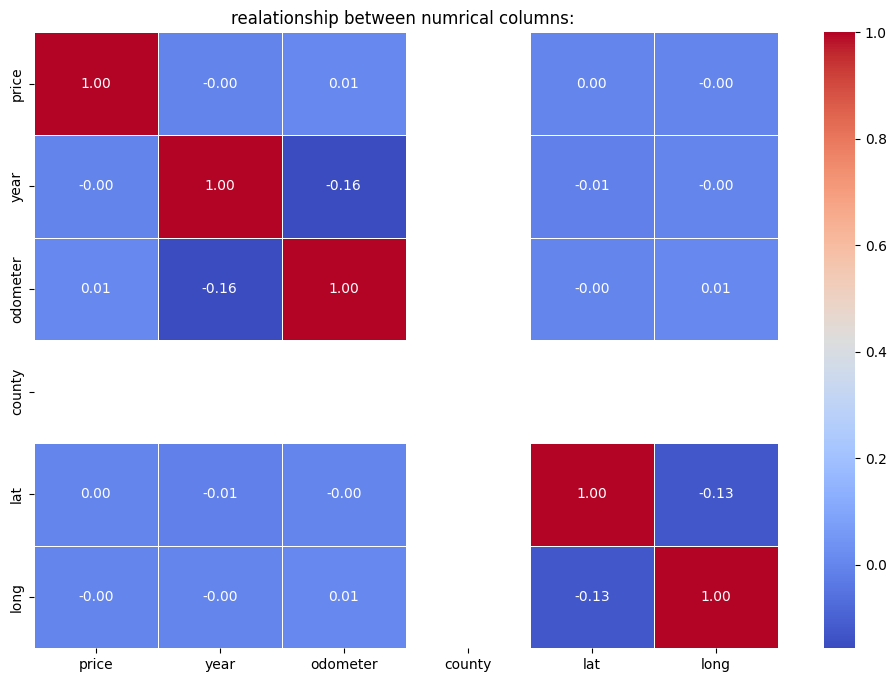

In [8]:
numeric_df = df_cars.select_dtypes(include=['int64', 'float64'])

# 2. حساب مصفوفة الارتباط
corr_matrix = numeric_df.corr()

# 3. رسم الخريطة الحرارية (Heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,
            annot=True,       # لإظهار الأرقام داخل المربعات
            cmap='coolwarm',  # اختيار ألوان توضح الموجب والسالب
            fmt=".2f",        # تقريب الأرقام لفاصلتين عشريتين
            linewidths=0.5)

plt.title("realationship between numrical columns: ")
plt.show()

In [9]:
missing_values = df_cars.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64


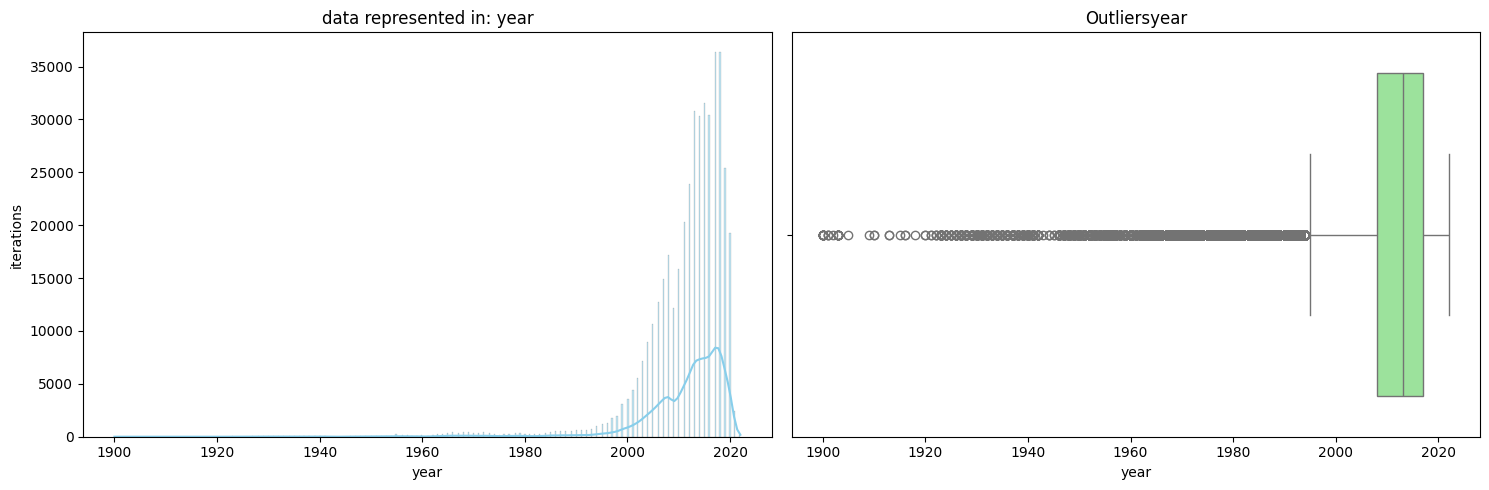

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_distribution_and_outliers(df, column_name):
    # إعداد مساحة الرسم (رسمتين جنب بعض)
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. رسم التوزيع (Histogram + KDE)
    sns.histplot(data=df, x=column_name, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'data represented in: {column_name}')
    axes[0].set_ylabel('iterations')

    # 2. رسم مخطط الصندوق لاكتشاف الشذوذ (Boxplot)
    sns.boxplot(data=df, x=column_name, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Outliers{column_name}')

    # عرض الرسم
    plt.tight_layout()
    plt.show()

# --- طريقة الاستخدام ---
# تحديد البيانات الرقمية فقط (لتجنب الأخطاء إذا مررت عمود نصي)
numeric_df = df_cars.select_dtypes(include=['int64', 'float64'])

# جرب الكود على عمود الدرجة النهائية G3
#plot_distribution_and_outliers(numeric_df, 'price')

# يمكنك تجربته على عمود آخر مشهور بالقيم الشاذة مثل الغيابات
plot_distribution_and_outliers(numeric_df, 'year')

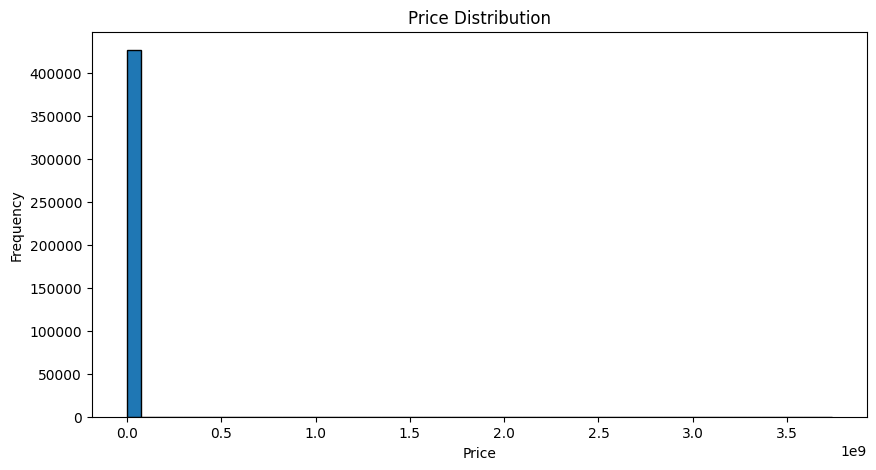

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(df_cars['price'].dropna(), bins=50, edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

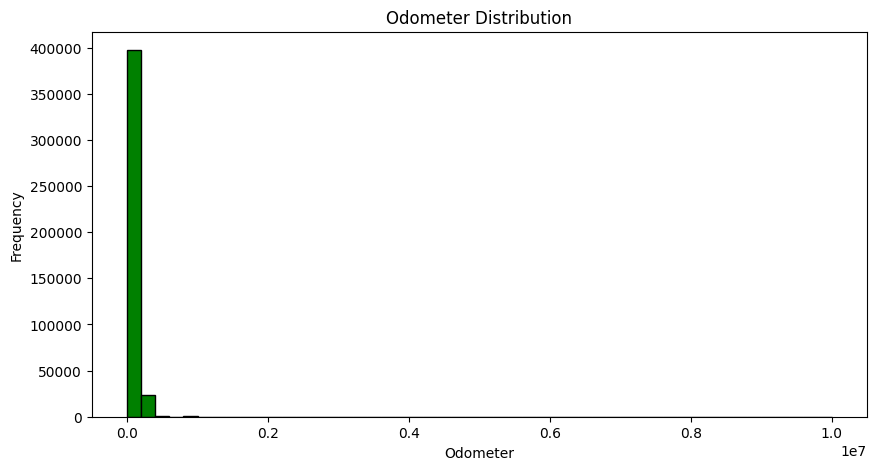

In [12]:
# Odometer distribution
plt.figure(figsize=(10, 5))
plt.hist(df_cars['odometer'].dropna(), bins=50, edgecolor='black', color='green')
plt.title('Odometer Distribution')
plt.xlabel('Odometer')
plt.ylabel('Frequency')
plt.show()

In [13]:
# الأعمدة التي تحتاج لمعالجة القيم الشاذة
columns_to_fix = ['price', 'odometer', 'year']

# حلقة تكرارية للمرور على الأعمدة وتصفيتها
for col in columns_to_fix:
    # تحديد الحد الأدنى (1%) والحد الأعلى (99%)
    q_low = df_cars[col].quantile(0.01)
    q_hi  = df_cars[col].quantile(0.99)

    # فلترة الإطار ليبقى فقط ضمن النطاق المنطقي
    df_cars = df_cars[(df_cars[col] >= q_low) & (df_cars[col] <= q_hi)]

print("تم تنظيف القيم الشاذة بنجاح!")

تم تنظيف القيم الشاذة بنجاح!


In [14]:
from sklearn.model_selection import train_test_split

# 1. فصل المميزات (X) عن المتغير المستهدف (y)
X = df_cars.drop('price', axis=1)
y = df_cars['price']

# 2. تقسيم البيانات إلى تدريب (80%) واختبار (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# طباعة الأبعاد للتأكد من نجاح التقسيم
print("شكل بيانات التدريب X_train:", X_train.shape)
print("شكل بيانات الاختبار X_test:", X_test.shape)
print("شكل بيانات التدريب y_train:", y_train.shape)
print("شكل بيانات الاختبار y_test:", y_test.shape)

شكل بيانات التدريب X_train: (322525, 20)
شكل بيانات الاختبار X_test: (80632, 20)
شكل بيانات التدريب y_train: (322525,)
شكل بيانات الاختبار y_test: (80632,)


In [15]:
from sklearn.impute import SimpleImputer

# 3. تحديد الأعمدة الرقمية والنصية
num_cols = X_train.select_dtypes(include=['number']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# 4. إعداد أدوات المعالجة (أضفنا keep_empty_features لمنع حذف الأعمدة)
num_imputer = SimpleImputer(strategy='median', keep_empty_features=True)
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown', keep_empty_features=True)

# 5. التطبيق المباشر على البيانات (استخدام .loc يضمن التوافق وتجنب مشاكل الفهارس)
X_train.loc[:, num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test.loc[:, num_cols]  = num_imputer.transform(X_test[num_cols])

X_train.loc[:, cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test.loc[:, cat_cols]  = cat_imputer.transform(X_test[cat_cols])

In [16]:
import pandas as pd

# إنشاء دالة لتطبيق الميزات الجديدة
def engineer_features(X):
    # نأخذ نسخة لتجنب تحذير التعديل المباشر على الإطار (SettingWithCopyWarning)
    X = X.copy()

    # 1. عمر السيارة
    X['age'] = 2026 - X['year']

    # تفادي مشكلة القسمة على صفر (في حال كانت السيارة موديل 2026 وعمرها 0)
    # نستبدل الصفر بـ 1 أو أي رقم صغير جداً لتجنب قيم Infinity
    X.loc[X['age'] == 0, 'age'] = 1

    # 2. المسافة المقطوعة في السنة
    X['miles_per_year'] = X['odometer'] / X['age']

    # 3. التفاعل بين العمر والمسافة
    X['age_x_miles_per_year'] = X['miles_per_year'] * X['age']

    return X

X_train = engineer_features(X_train)
X_test = engineer_features(X_test)


X_train[['year', 'age', 'odometer', 'miles_per_year', 'age_x_miles_per_year']].head()

,year,age,odometer,miles_per_year,age_x_miles_per_year
328923,2014.0,12.0,150552.0,12546.000000,150552.0
243931,2005.0,21.0,107000.0,5095.238095,107000.0
125467,2015.0,11.0,77833.0,7075.727273,77833.0
182916,2017.0,9.0,68171.0,7574.555556,68171.0
125758,2011.0,15.0,111000.0,7400.000000,111000.0


In [17]:
df_cars.head()

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,VIN,drive,size,type,paint_color,county,state,lat,long,posting_date
27,auburn,33590,2014.0,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,...,3GTP1VEC4EG551563,NaN,NaN,pickup,white,NaN,al,32.590,-85.4800,2021-05-04T12:31:18-0500
28,auburn,22590,2010.0,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,...,1GCSCSE06AZ123805,NaN,NaN,pickup,blue,NaN,al,32.590,-85.4800,2021-05-04T12:31:08-0500
29,auburn,39590,2020.0,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,...,3GCPWCED5LG130317,NaN,NaN,pickup,red,NaN,al,32.590,-85.4800,2021-05-04T12:31:25-0500
30,auburn,30990,2017.0,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,...,5TFRM5F17HX120972,NaN,NaN,pickup,red,NaN,al,32.590,-85.4800,2021-05-04T10:41:31-0500
31,auburn,15000,2013.0,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,...,NaN,rwd,full-size,truck,black,NaN,al,32.592,-85.5189,2021-05-03T14:02:03-0500


In [18]:
df_cars.tail(10)

,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,...,VIN,drive,size,type,paint_color,county,state,lat,long,posting_date
426870,wyoming,22990,2020.0,hyundai,sonata se sedan 4d,good,NaN,gas,3066.0,clean,...,5NPEG4JAXLH051710,fwd,NaN,sedan,blue,NaN,wy,33.786500,-84.445400,2021-04-04T03:40:17-0600
426871,wyoming,17990,2018.0,kia,sportage lx sport utility 4d,good,NaN,gas,34239.0,clean,...,KNDPMCAC7J7417329,NaN,NaN,SUV,NaN,NaN,wy,33.786500,-84.445400,2021-04-04T03:30:20-0600
426872,wyoming,32590,2020.0,mercedes-benz,c-class c 300,good,NaN,gas,19059.0,clean,...,55SWF8DB6LU325050,rwd,NaN,sedan,white,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:35-0600
426873,wyoming,30990,2018.0,mercedes-benz,glc 300 sport,good,NaN,gas,15080.0,clean,...,WDC0G4JB6JV019749,rwd,NaN,other,white,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:35-0600
426874,wyoming,33590,2018.0,lexus,gs 350 sedan 4d,good,6 cylinders,gas,30814.0,clean,...,JTHBZ1BLXJA012999,rwd,NaN,sedan,white,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:34-0600
426875,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,...,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,...,7JR102FKXLG042696,fwd,NaN,sedan,red,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,...,1GYFZFR46LF088296,NaN,NaN,hatchback,white,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,...,58ABK1GG4JU103853,fwd,NaN,sedan,silver,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,...,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


In [19]:
from sklearn.preprocessing import OrdinalEncoder

# 1. إعداد أداة الترميز
# السطر أدناه هو السر الذي يجعله قابلاً للاستخدام في أي مكان:
# سيقوم بإعطاء القيمة (-1) لأي فئة جديدة تظهر في X_test ولم تكن موجودة في X_train لتجنب توقف الكود.
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 2. التطبيق المباشر على الأعمدة النصية (cat_cols) التي حددناها في الخطوة السابقة
# نستخدم .loc لضمان الاستقرار وتجنب مشاكل الفهارس في Pandas
X_train.loc[:, cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test.loc[:, cat_cols]  = encoder.transform(X_test[cat_cols])

print("تم تحويل جميع البيانات النصية إلى أرقام بنجاح!")

تم تحويل جميع البيانات النصية إلى أرقام بنجاح!


In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. إعداد أداة التقييس
scaler = StandardScaler()

# 2. تطبيق التقييس (Scaling)
# نستخدم fit_transform لبيانات التدريب (لتعلم المتوسط والانحراف المعياري وتطبيقه)
X_train_scaled_array = scaler.fit_transform(X_train)

# نستخدم transform فقط لبيانات الاختبار (نطبق ما تعلمناه من التدريب لمنع تسرب البيانات)
X_test_scaled_array  = scaler.transform(X_test)

# 3. إعادتها إلى إطار بيانات Pandas للحفاظ على أسماء الأعمدة (خطوة تنظيمية ممتازة)
X_train = pd.DataFrame(X_train_scaled_array, columns=X_train.columns, index=X_train.index)
X_test  = pd.DataFrame(X_test_scaled_array, columns=X_test.columns, index=X_test.index)

print("تم عمل Scaling للبيانات بنجاح، وهي الآن جاهزة 100% لإدخالها في خوارزميات تعلم الآلة!")

تم عمل Scaling للبيانات بنجاح، وهي الآن جاهزة 100% لإدخالها في خوارزميات تعلم الآلة!


In [21]:
# 1. التحقق من أبعاد البيانات (عدد الصفوف والأعمدة)
print("أبعاد X_train:", X_train.shape)
print("أبعاد X_test:", X_test.shape)
print("-" * 50)

# 2. عرض أول 5 صفوف للتأكد من شكل القيم الجديدة
print("أول 5 صفوف من بيانات التدريب:")
display(X_train.head())
print("-" * 50)

# 3. التحقق الإحصائي السريع (أهم خطوة للتأكد من نجاح الـ StandardScaler)
# يجب أن يكون صف الـ mean تقريباً 0 وصف الـ std تقريباً 1 لجميع الأعمدة
print("الملخص الإحصائي لبيانات التدريب بعد التقييس:")
display(X_train.describe().round(3))

أبعاد X_train: (322525, 23)
أبعاد X_test: (80632, 23)
--------------------------------------------------
أول 5 صفوف من بيانات التدريب:


,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,...,type,paint_color,county,state,lat,long,posting_date,age,miles_per_year,age_x_miles_per_year
328923,-0.807267,0.298689,-1.179996,-1.729434,-0.973626,0.918275,-0.017078,0.977109,-0.144748,-0.481067,...,0.969258,-0.794740,0.0,0.945726,0.567192,0.732814,-1.517233,-0.298689,1.704006,0.977109
243931,1.689813,-0.947121,-0.930747,-1.246230,-0.973626,0.918275,-0.017078,0.248687,-0.144748,-0.481067,...,-1.012510,-1.011752,0.0,0.219098,-1.003784,0.794069,-1.420435,0.947121,-0.392500,0.248687
125467,-1.079058,0.437113,-0.681497,0.244354,1.162396,-0.392507,-0.017078,-0.239141,-0.144748,2.239063,...,-1.232707,-1.011752,0.0,-0.903874,-1.041449,0.523064,-1.720719,-0.437113,0.164773,-0.239141
182916,-1.478251,0.713959,0.149334,0.612778,-0.973626,-1.703290,-0.017078,-0.400741,-0.144748,-0.481067,...,-1.232707,0.941351,0.0,-0.243302,0.102163,0.960895,-0.853683,-0.713959,0.305134,-0.400741
125758,0.059067,-0.116581,-0.930747,-0.440889,-0.261619,-1.703290,-0.017078,0.315589,-0.144748,-0.481067,...,-1.012510,-0.794740,0.0,-0.903874,-0.989598,0.591842,-0.288422,0.116581,0.256017,0.315589


--------------------------------------------------
الملخص الإحصائي لبيانات التدريب بعد التقييس:


,region,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,...,type,paint_color,county,state,lat,long,posting_date,age,miles_per_year,age_x_miles_per_year
count,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,...,322525.000,322525.000,322525.0,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000,322525.000
mean,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000,...,-0.000,-0.000,0.0,0.000,0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,...,1.000,1.000,0.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.648,-6.069,-1.595,-2.036,-0.974,-3.669,-3.859,-1.541,-1.527,-1.841,...,-1.233,-1.012,0.0,-1.564,-19.239,-3.591,-1.740,-1.129,-1.826,-1.541
25%,-0.952,-0.393,-0.931,-0.754,-0.974,-0.393,-0.017,-0.862,-0.145,-0.481,...,-1.013,-1.012,0.0,-0.970,-0.640,-0.916,-0.865,-0.714,-0.751,-0.862
50%,0.025,0.299,-0.349,-0.005,-0.262,0.263,-0.017,-0.077,-0.145,-0.481,...,0.088,-0.578,0.0,-0.045,0.115,0.346,0.007,-0.299,-0.036,-0.077
75%,0.815,0.714,0.814,0.903,1.162,0.918,-0.017,0.699,-0.145,-0.481,...,0.969,1.158,0.0,0.880,0.662,0.745,0.868,0.393,0.640,0.699
max,1.775,1.129,1.894,1.674,3.298,1.574,2.544,3.141,6.766,2.239,...,1.630,1.592,0.0,1.738,7.594,14.381,1.715,6.069,7.706,3.141


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. إعداد نموذج الغابة العشوائية (Random Forest)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 2. تقييم النموذج باستخدام K-Fold Cross Validation (5 طيات)
print("جاري تقييم النموذج باستخدام K-Fold (قد يستغرق بعض الوقت للبيانات الضخمة)...")
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# سنستخدم مقياس R-squared لتقييم الطيات لمعرفة مدى استقرار دقة النموذج
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

print("نتائج K-Fold Cross Validation:")
print(f"- درجات الدقة للطيات الخمس: {np.round(cv_scores, 4)}")
print(f"- متوسط الدقة العام (R-squared): {cv_scores.mean():.4f}")
print("-" * 50)

جاري تقييم النموذج باستخدام K-Fold (قد يستغرق بعض الوقت للبيانات الضخمة)...
نتائج K-Fold Cross Validation:
- درجات الدقة للطيات الخمس: [0.8553 0.854  0.8548 0.8535 0.849 ]
- متوسط الدقة العام (R-squared): 0.8533
--------------------------------------------------


In [23]:
# طباعة أسماء الأعمدة في X_train
print(X_train.columns.tolist())

['region', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'county', 'state', 'lat', 'long', 'posting_date', 'age', 'miles_per_year', 'age_x_miles_per_year']


In [24]:
# 3. تدريب النموذج بشكل نهائي على كامل بيانات التدريب
print("جاري تدريب النموذج النهائي...")
rf_model.fit(X_train, y_train)

# 4. التنبؤ بالقيم المخفية (بيانات الاختبار X_test)
y_pred = rf_model.predict(X_test)

# 5. حساب مقاييس الأداء للمقارنة
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# 6. طباعة النتائج النهائية بشكل مرتب
print("نتائج تقييم النموذج النهائي على بيانات الاختبار (القيم المخفية):")
print(f"MAE  (متوسط الخطأ المطلق)      : {mae:,.2f}")
print(f"MSE  (متوسط مربع الخطأ)        : {mse:,.2f}")
print(f"RMSE (جذر متوسط مربع الخطأ)    : {rmse:,.2f}")
print(f"R²   (معامل التحديد - الدقة)   : {r2:.4f}")

جاري تدريب النموذج النهائي...
نتائج تقييم النموذج النهائي على بيانات الاختبار (القيم المخفية):
MAE  (متوسط الخطأ المطلق)      : 3,418.46
MSE  (متوسط مربع الخطأ)        : 36,877,888.24
RMSE (جذر متوسط مربع الخطأ)    : 6,072.72
R²   (معامل التحديد - الدقة)   : 0.8038


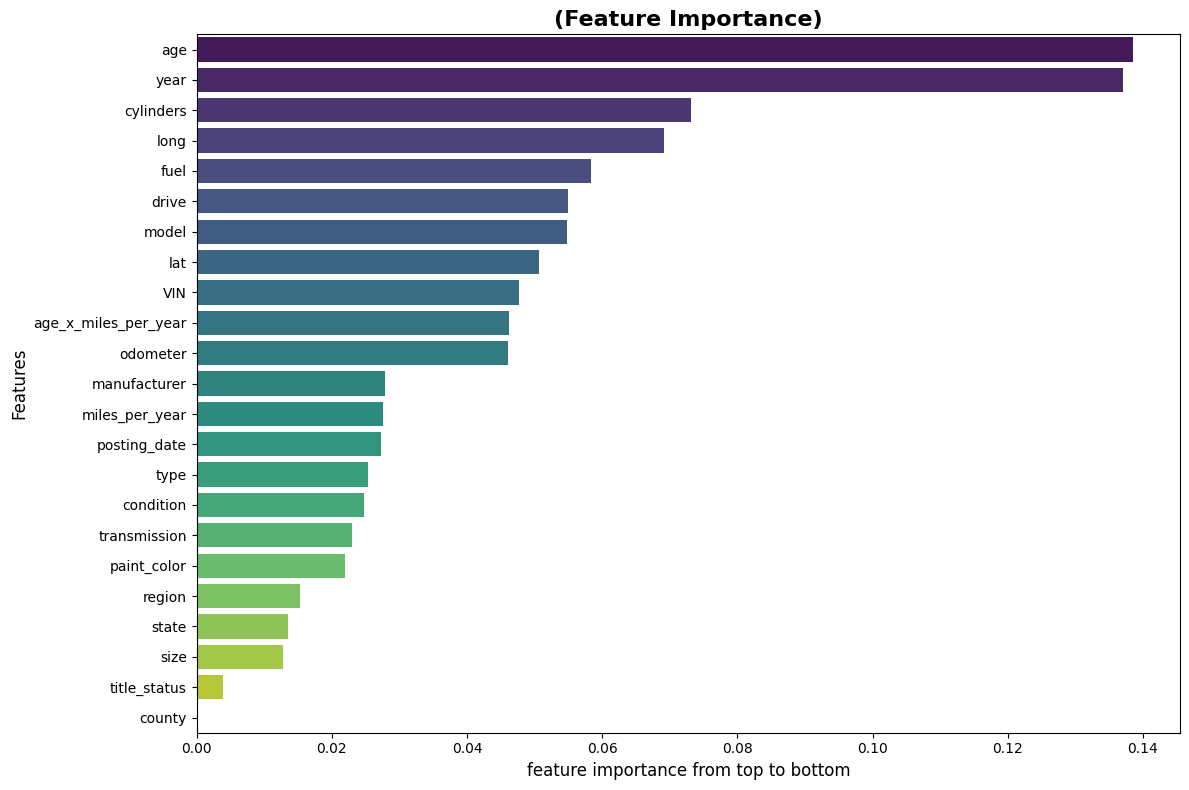

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. استخراج قيم الأهمية وأسماء الأعمدة من النموذج وبيانات التدريب
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. إنشاء إطار بيانات (DataFrame) لترتيب القيم
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# 3. ترتيب الأعمدة تنازلياً من الأهم إلى الأقل أهمية
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 4. رسم البيانات
plt.figure(figsize=(12, 8))
# استخدمنا مكتبة seaborn لجعل الرسم البياني أكثر احترافية ووضوحاً
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')

# 5. إضافة العناوين والتنسيقات
plt.title('(Feature Importance)', fontsize=16, weight='bold')
plt.xlabel('feature importance from top to bottom', fontsize=12)
plt.ylabel('Features', fontsize=12)

plt.tight_layout()
plt.show()